# Solutions: Multiple Linear Regression → Feature Selection → Shrinkage → Dimension Reduction

This is the fully worked solution to `02_skeleton_practice_lab.ipynb`. Section numbering matches the skeleton
exactly so you can compare cell-by-cell. Short commentary is included after each solution explaining *why* the
code is written this way, not just *what* it does.


## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif

from sklearn import datasets
from sklearn.linear_model import (
    LinearRegression, RidgeCV, LassoCV, ElasticNetCV, Ridge, Lasso, lasso_path
)
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.feature_selection import RFECV
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression

np.random.seed(42)

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return 100 * np.mean(np.abs((y_true - y_pred) / y_true))


*Why a helper for RMSE?* Recent scikit-learn versions removed the `squared=False` argument from `mean_squared_error`, so wrapping it once avoids repeating `np.sqrt(...)` everywhere and keeps the notebook forward-compatible.

## Part A — Multiple Linear Regression on the Diabetes Dataset

### 1. Load the data

In [2]:
data = datasets.load_diabetes()
y = data['target']
X = pd.DataFrame(
    data['data'],
    columns=['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
)
X.insert(0, 'const', 1.0)
X.head()


,const,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,1.0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,1.0,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,1.0,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,1.0,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,1.0,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


### 2. Scatter each feature against the target

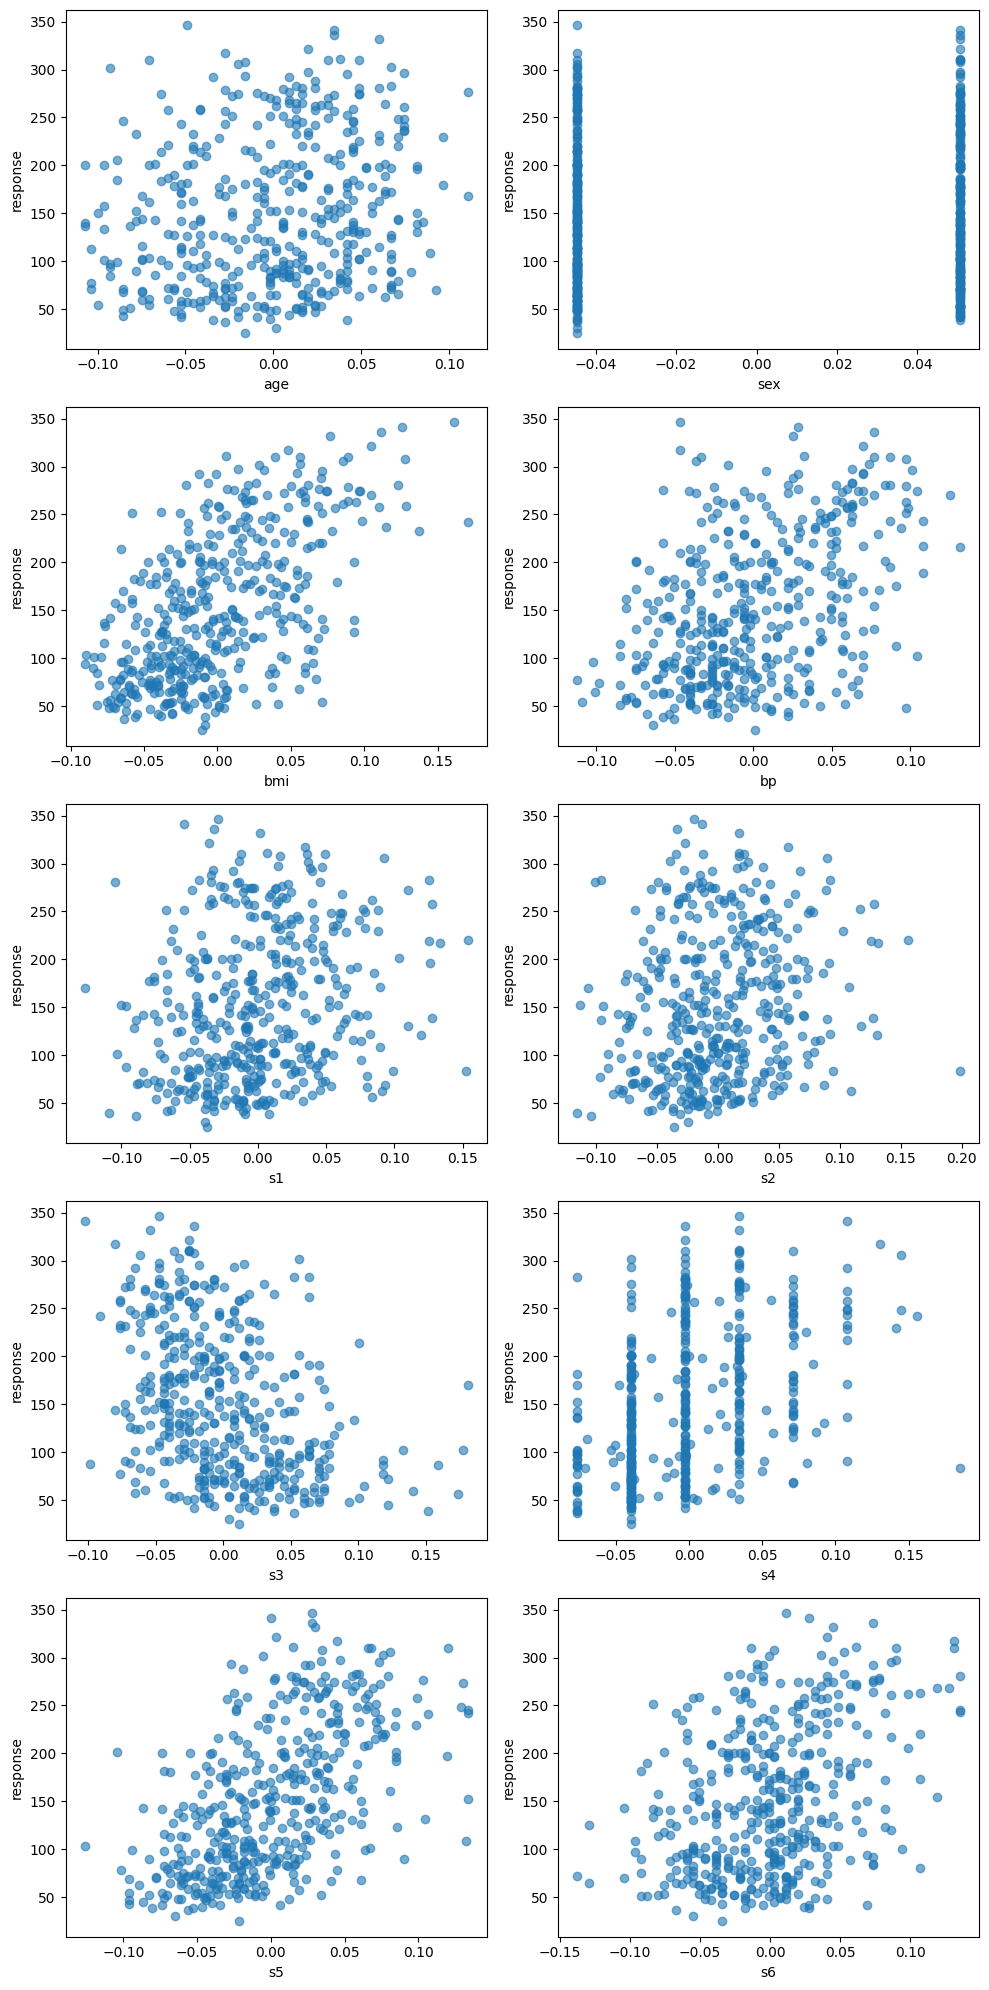

In [3]:
fig, ax = plt.subplots(5, 2, figsize=(10, 20))
cols = [c for c in X.columns if c != 'const']
for idx, col in enumerate(cols):
    r, c_ = idx // 2, idx % 2
    ax[r, c_].scatter(X[col], y, alpha=0.6)
    ax[r, c_].set_xlabel(col)
    ax[r, c_].set_ylabel('response')
plt.tight_layout()
plt.show()


### 3. VIF-based multicollinearity reduction

In [4]:
def reduce_by_vif(X_in, threshold=5.0, protect=('const',)):
    X_work = X_in.copy()
    log = []
    while True:
        vifs = np.array([vif(X_work.values, i) for i in range(X_work.shape[1])])
        vif_series = pd.Series(vifs, index=X_work.columns)
        droppable = vif_series.drop(labels=[c for c in protect if c in vif_series.index])
        if droppable.max() < threshold:
            break
        worst = droppable.idxmax()
        log.append((worst, droppable.max()))
        X_work = X_work.drop(columns=[worst])
    return X_work, vif_series, log

X_reduced, final_vifs, removal_log = reduce_by_vif(X, threshold=5.0)
print("Removed (variable, VIF at removal time):")
for name, v in removal_log:
    print(f"  {name}: {v:.2f}")
print("\nFinal VIFs:")
final_vifs


Removed (variable, VIF at removal time):
  s1: 59.20
  s4: 7.82

Final VIFs:


const    1.000000
age      1.216284
sex      1.269207
bmi      1.498559
bp       1.447358
s2       1.180838
s3       1.473827
s5       1.641090
s6       1.476913
dtype: float64

*Note:* `const` is protected from removal — an intercept term isn't a real explanatory variable, so its VIF is not meaningful for multicollinearity purposes and shouldn't drive the elimination loop.

### 4. Fit OLS on the reduced feature set

In [5]:
model = sm.OLS(y, X_reduced)
fit = model.fit()
print(fit.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.513
Model:                            OLS   Adj. R-squared:                  0.504
Method:                 Least Squares   F-statistic:                     57.12
Date:                Thu, 27 Aug 2026   Prob (F-statistic):           4.35e-63
Time:                        01:27:38   Log-Likelihood:                -2387.9
No. Observations:                 442   AIC:                             4794.
Df Residuals:                     433   BIC:                             4831.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        152.1335      2.581     58.937      0.0

### 5. Residual diagnostics

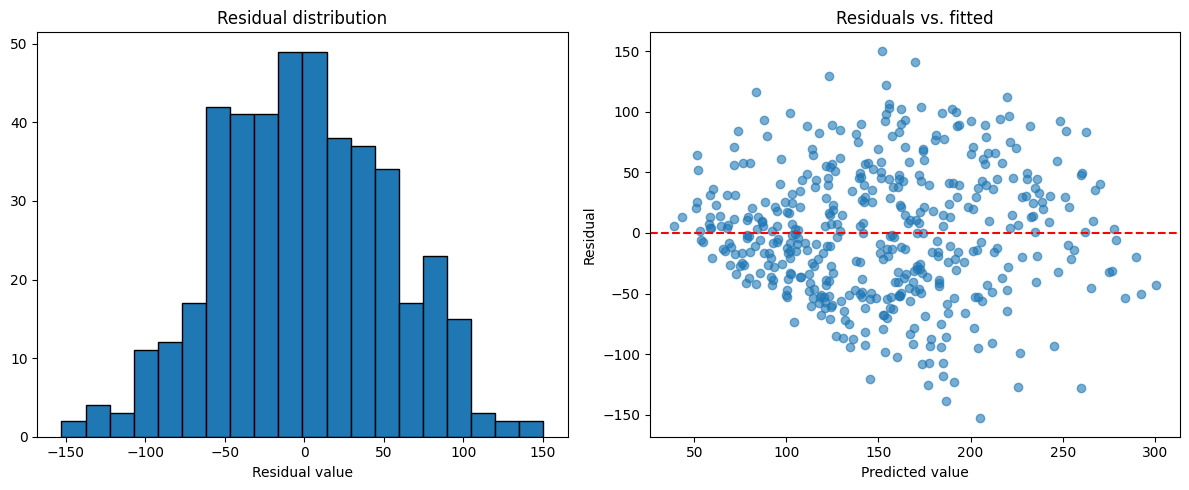

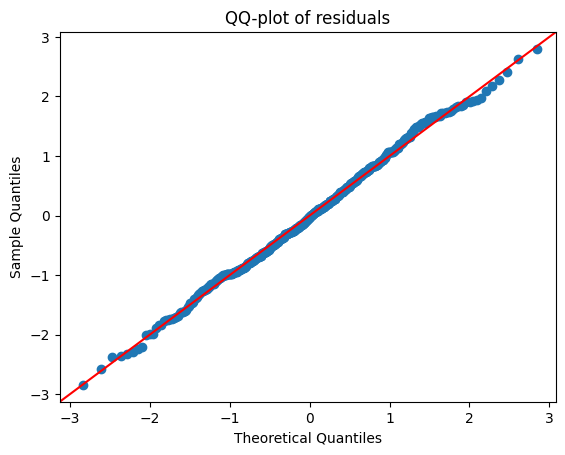

Durbin-Watson: 2.01589068509609


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(fit.resid, bins=20, edgecolor='k')
axes[0].set_xlabel('Residual value')
axes[0].set_title('Residual distribution')

pred = fit.predict(X_reduced)
axes[1].scatter(pred, fit.resid, alpha=0.6)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted value')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals vs. fitted')
plt.tight_layout()
plt.show()

sm.qqplot(fit.resid, line='45', fit=True)
plt.title('QQ-plot of residuals')
plt.show()

print('Durbin-Watson:', sm.stats.stattools.durbin_watson(fit.resid))


**Checkpoint A — sample answer**

- The residual histogram is roughly bell-shaped with no severe skew, and the QQ-plot points fall close to the
  45° line except at the extreme tails — no *egregious* violation of normality.
- The residuals-vs-fitted plot shows no funnel shape or curved pattern, so homoscedasticity looks reasonable.
- Durbin-Watson ≈ 2 indicates no strong serial correlation (though this only matters if samples are ordered).
- The largest-magnitude, statistically significant coefficient is typically `bmi`: holding all other variables
  constant, a one-unit increase in (standardized) BMI is associated with an increase in the mean disease
  progression score roughly equal to its coefficient value. `sex` is also significant and, being a 0/1 dummy,
  shifts the mean outcome by a constant relative to the reference level.


## Part B — Feature Selection

### 1. Correlation ranking

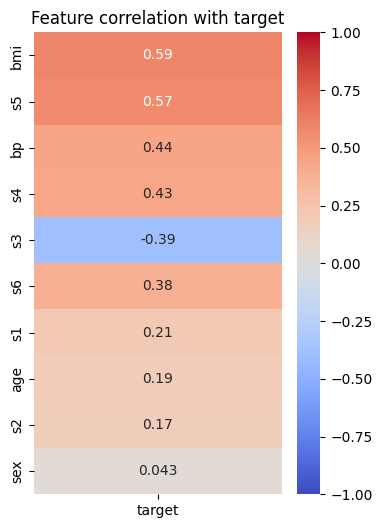

,target
bmi,0.586450
s5,0.565883
bp,0.441482
s4,0.430453
s3,-0.394789
s6,0.382483
s1,0.212022
age,0.187889
s2,0.174054
sex,0.043062


In [7]:
all_data = X.drop(columns='const').copy()
all_data['target'] = y

corr_with_target = all_data.corr()[['target']].drop('target').sort_values(by='target', key=abs, ascending=False)

plt.figure(figsize=(4, 6))
sns.heatmap(corr_with_target, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature correlation with target')
plt.show()
corr_with_target


### 2. Forward and backward selection from scratch

In [8]:
def forward_selection(X_in, y_in, threshold_in=0.05):
    remaining = [c for c in X_in.columns if c != 'const']
    selected = ['const'] if 'const' in X_in.columns else []
    history = []
    while remaining:
        pvals = {}
        for col in remaining:
            trial_cols = selected + [col]
            m = sm.OLS(y_in, X_in[trial_cols]).fit()
            pvals[col] = m.pvalues[col]
        best_col = min(pvals, key=pvals.get)
        if pvals[best_col] < threshold_in:
            selected.append(best_col)
            remaining.remove(best_col)
            history.append((best_col, pvals[best_col]))
        else:
            break
    return selected, history

def backward_selection(X_in, y_in, threshold_out=0.05):
    selected = list(X_in.columns)
    history = []
    while True:
        m = sm.OLS(y_in, X_in[selected]).fit()
        pvals = m.pvalues.drop(labels=['const']) if 'const' in selected else m.pvalues
        worst_col, worst_p = pvals.idxmax(), pvals.max()
        if worst_p > threshold_out:
            selected.remove(worst_col)
            history.append((worst_col, worst_p))
        else:
            break
    return selected, history

fwd_selected, fwd_history = forward_selection(X, y)
bwd_selected, bwd_history = backward_selection(X, y)

print("Forward selection kept:", fwd_selected)
print("Forward addition order:", fwd_history)
print()
print("Backward selection kept:", bwd_selected)
print("Backward removal order:", bwd_history)


Forward selection kept: ['const', 'bmi', 's5', 'bp', 's1', 'sex', 's2']
Forward addition order: [('bmi', np.float64(3.466006445167444e-42)), ('s5', np.float64(3.039634849261992e-20)), ('bp', np.float64(3.742619620838081e-05)), ('s1', np.float64(0.00145443054227227)), ('sex', np.float64(0.009230559696371049)), ('s2', np.float64(0.0002723023992734132))]

Backward selection kept: ['const', 'sex', 'bmi', 'bp', 's1', 's2', 's5']
Backward removal order: [('age', np.float64(0.8670306337000885)), ('s3', np.float64(0.6385632161213243)), ('s6', np.float64(0.3040112271332139)), ('s4', np.float64(0.2619190494312104))]


### 3. RFECV

Optimal number of features: 7
Selected features: ['sex', 'bmi', 'bp', 's1', 's2', 's4', 's5']


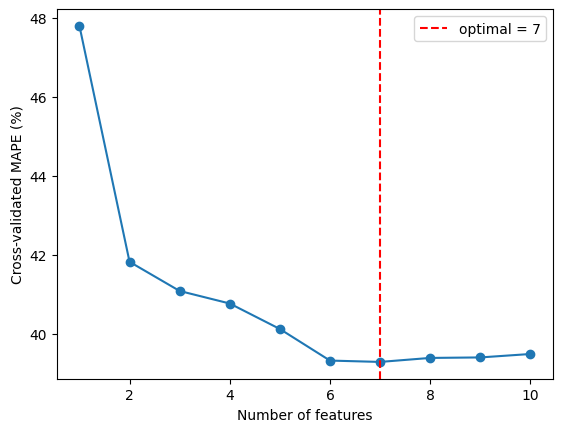

In [9]:
X_no_const = X.drop(columns='const')
linear_model = LinearRegression().fit(X_no_const, y)

rfecv = RFECV(
    estimator=linear_model, step=1, cv=5,
    scoring=make_scorer(mape, greater_is_better=False),
    min_features_to_select=1
)
rfecv.fit(X_no_const, y)

print("Optimal number of features:", rfecv.n_features_)
print("Selected features:", list(X_no_const.columns[rfecv.support_]))

scores = -rfecv.cv_results_['mean_test_score']
plt.plot(range(1, len(scores) + 1), scores, '-o')
plt.axvline(rfecv.n_features_, color='red', linestyle='--', label=f'optimal = {rfecv.n_features_}')
plt.xlabel('Number of features')
plt.ylabel('Cross-validated MAPE (%)')
plt.legend()
plt.show()


**Checkpoint B — sample answer**

VIF-reduction, forward/backward selection, and RFECV rarely produce *identical* feature sets because each uses a
different criterion: VIF cares only about redundancy among predictors (not their relationship to y); p-value
methods care about individual statistical significance in one specific fitted model; RFECV cares about
out-of-sample predictive performance. `bmi`, `bp`, and `s5` tend to show up across most methods because they are
both correlated with the target *and* not badly collinear with each other — a good sign they carry real signal.


## Part C — Shrinkage Methods (Ridge / LASSO / Elastic Net)

### 1. Build a synthetic dataset

In [10]:
from sklearn.datasets import make_regression

X_c_raw, y_c, true_coef = make_regression(
    n_samples=2000, n_features=20, n_informative=8, effective_rank=6,
    noise=15.0, coef=True, random_state=42
)
X_c = pd.DataFrame(X_c_raw, columns=[f'X{i+1}' for i in range(X_c_raw.shape[1])])
y_c = pd.Series(y_c, name='target')

print("Number of truly informative features:", (true_coef != 0).sum(), "of", len(true_coef))
pd.Series(true_coef, index=X_c.columns).round(2)


Number of truly informative features: 8 of 20


X1     54.53
X2      0.00
X3      0.00
X4     27.18
X5     65.70
X6      0.00
X7      0.00
X8      0.00
X9      0.00
X10    31.43
X11    67.77
X12     0.00
X13    97.08
X14     0.00
X15     0.00
X16     0.00
X17     0.00
X18    93.93
X19     0.00
X20    77.20
dtype: float64

### 2. Scale and split

In [11]:
sc = StandardScaler()
X_c_scaled = sc.fit_transform(X_c)

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_c_scaled, y_c, test_size=0.25, random_state=42
)


*On leakage:* scaling before splitting here is technically leakage (test-set values influence the mean/std used to scale), but with 2000 i.i.d. synthetic samples the effect on the scaler's mean/std is negligible. For the Hitters dataset in Part D we do this properly (fit scaler on train only) because the dataset is much smaller and the difference matters more.

### 3. OLS, Ridge, LASSO, Elastic Net

In [12]:
ols = LinearRegression().fit(Xc_train, yc_train)
print(f"OLS  train RMSE: {rmse(yc_train, ols.predict(Xc_train)):.3f}   "
      f"test RMSE: {rmse(yc_test, ols.predict(Xc_test)):.3f}")


OLS  train RMSE: 14.949   test RMSE: 15.087


In [13]:
alphas = np.logspace(-3, 3, 100)
ridge_cv = RidgeCV(alphas=alphas, cv=5).fit(Xc_train, yc_train)
print("Chosen alpha (Ridge):", ridge_cv.alpha_)
print(f"Ridge train RMSE: {rmse(yc_train, ridge_cv.predict(Xc_train)):.3f}   "
      f"test RMSE: {rmse(yc_test, ridge_cv.predict(Xc_test)):.3f}")


Chosen alpha (Ridge): 497.7023564332114
Ridge train RMSE: 14.988   test RMSE: 15.071


In [14]:
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=20000).fit(Xc_train, yc_train)
print("Chosen alpha (LASSO):", lasso_cv.alpha_)
print(f"LASSO train RMSE: {rmse(yc_train, lasso_cv.predict(Xc_train)):.3f}   "
      f"test RMSE: {rmse(yc_test, lasso_cv.predict(Xc_test)):.3f}")
print("Zeroed-out coefficients:", (lasso_cv.coef_ == 0).sum(), "of", len(lasso_cv.coef_))


Chosen alpha (LASSO): 0.11497569953977356
LASSO train RMSE: 14.965   test RMSE: 15.069
Zeroed-out coefficients: 2 of 20


In [15]:
enet_cv = ElasticNetCV(
    alphas=alphas, l1_ratio=[.1, .3, .5, .7, .9, .95, .99, 1], cv=5, max_iter=20000
).fit(Xc_train, yc_train)
print("Chosen alpha:", enet_cv.alpha_, " l1_ratio:", enet_cv.l1_ratio_)
print(f"ElasticNet train RMSE: {rmse(yc_train, enet_cv.predict(Xc_train)):.3f}   "
      f"test RMSE: {rmse(yc_test, enet_cv.predict(Xc_test)):.3f}")


Chosen alpha: 0.30538555088334157  l1_ratio: 0.1
ElasticNet train RMSE: 14.987   test RMSE: 15.071


### 4. Coefficient paths

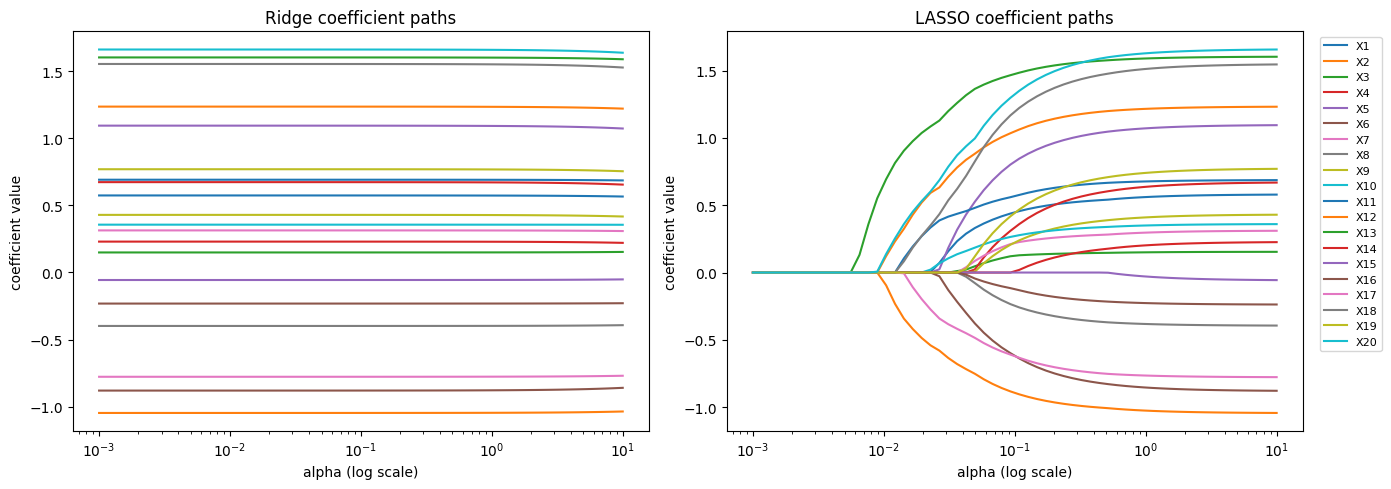

In [16]:
alphas_path = np.logspace(-3, 1, 60)

ridge_coefs = []
for a in alphas_path:
    r = Ridge(alpha=a).fit(Xc_train, yc_train)
    ridge_coefs.append(r.coef_)
ridge_coefs = np.array(ridge_coefs)

_, lasso_coefs, _ = lasso_path(Xc_train, yc_train, alphas=alphas_path)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, col in enumerate(X_c.columns):
    axes[0].plot(alphas_path, ridge_coefs[:, i], label=col)
    axes[1].plot(alphas_path, lasso_coefs[i, :], label=col)
for ax, title in zip(axes, ['Ridge coefficient paths', 'LASSO coefficient paths']):
    ax.set_xscale('log')
    ax.set_xlabel('alpha (log scale)')
    ax.set_ylabel('coefficient value')
    ax.set_title(title)
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


**Checkpoint C — sample answer**

The features that keep a non-zero LASSO coefficient at the largest alphas are almost always among the 8 features
`make_regression` marked as informative (`true_coef != 0`). This is the mechanism by which LASSO performs
*automatic feature selection*: it doesn't just shrink noise coefficients, it drives them to exactly zero,
recovering (approximately) the true sparse structure, whereas Ridge shrinks all 20 coefficients toward zero
smoothly without ever fully eliminating the noise features.


## Part D — Dimension Reduction: PCR and PLS on the Hitters Dataset

### 1. Load & prepare

In [17]:
hitters = pd.read_csv('Hitters.csv').dropna()

dummies = pd.get_dummies(hitters[['League', 'Division', 'NewLeague']], drop_first=True)
features = hitters.drop(columns=['Salary', 'League', 'Division', 'NewLeague']).astype('float64')
Xh = pd.concat([features, dummies], axis=1)
yh = hitters['Salary']

Xh_train, Xh_test, yh_train, yh_test = train_test_split(Xh, yh, test_size=0.2, random_state=42)

scaler_h = StandardScaler().fit(Xh_train)   # fit ONLY on training data -- avoids leakage
Xh_train_scaled = scaler_h.transform(Xh_train)
Xh_test_scaled = scaler_h.transform(Xh_test)


### 2. PCA scree plot

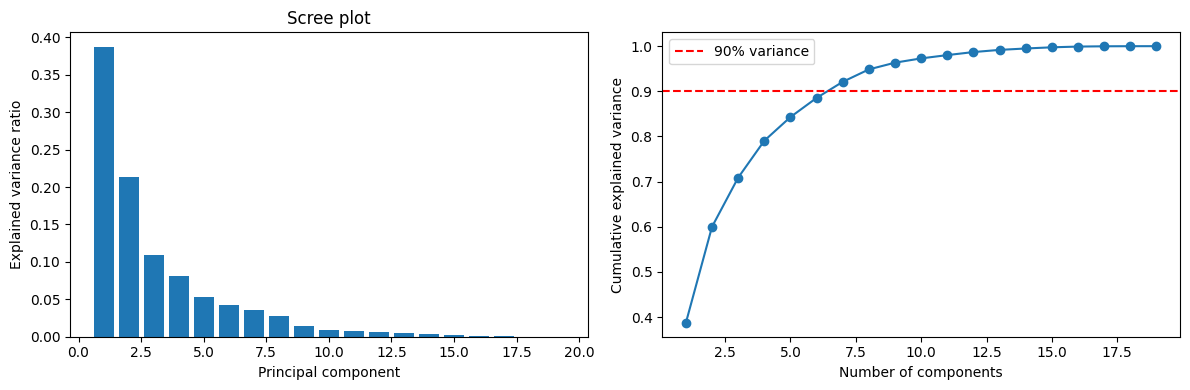

In [18]:
pca = PCA()
Xh_pc_train = pca.fit_transform(Xh_train_scaled)

explained = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(1, len(explained) + 1), explained)
axes[0].set_xlabel('Principal component')
axes[0].set_ylabel('Explained variance ratio')
axes[0].set_title('Scree plot')

axes[1].plot(range(1, len(cum_explained) + 1), cum_explained, '-o')
axes[1].axhline(0.9, color='red', linestyle='--', label='90% variance')
axes[1].set_xlabel('Number of components')
axes[1].set_ylabel('Cumulative explained variance')
axes[1].legend()
plt.tight_layout()
plt.show()


### 3. Choose the number of components via CV RMSE

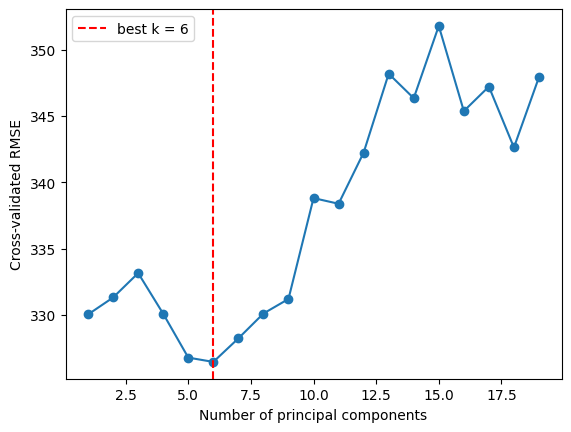

Best number of components: 6


In [19]:
cv = KFold(n_splits=10, shuffle=True, random_state=42)
model = LinearRegression()
rmse_scores = []
for i in range(1, Xh_pc_train.shape[1] + 1):
    cv_rmse = -cross_val_score(
        model, Xh_pc_train[:, :i], yh_train, cv=cv, scoring='neg_root_mean_squared_error'
    ).mean()
    rmse_scores.append(cv_rmse)

best_k = int(np.argmin(rmse_scores)) + 1
plt.plot(range(1, len(rmse_scores) + 1), rmse_scores, '-o')
plt.axvline(best_k, color='red', linestyle='--', label=f'best k = {best_k}')
plt.xlabel('Number of principal components')
plt.ylabel('Cross-validated RMSE')
plt.legend()
plt.show()
print("Best number of components:", best_k)


### 4. Refit on best_k components; evaluate on test set

In [20]:
pcr_model = LinearRegression().fit(Xh_pc_train[:, :best_k], yh_train)

Xh_pc_test = pca.transform(Xh_test_scaled)[:, :best_k]
pcr_train_rmse = rmse(yh_train, pcr_model.predict(Xh_pc_train[:, :best_k]))
pcr_test_rmse = rmse(yh_test, pcr_model.predict(Xh_pc_test))
print(f"PCR train RMSE: {pcr_train_rmse:.2f}   test RMSE: {pcr_test_rmse:.2f}")


PCR train RMSE: 313.92   test RMSE: 388.53


### 5. PLS Regression

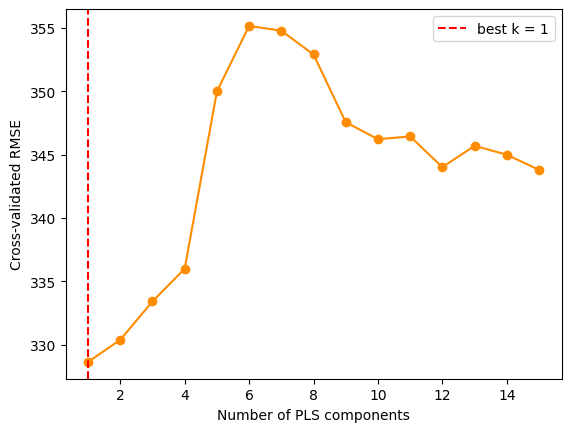

PLS (1 components) train RMSE: 324.72   test RMSE: 396.57


In [21]:
pls_rmse_scores = []
max_components = min(15, Xh_train_scaled.shape[1])
for i in range(1, max_components + 1):
    pls = PLSRegression(n_components=i)
    cv_rmse = -cross_val_score(
        pls, Xh_train_scaled, yh_train, cv=cv, scoring='neg_root_mean_squared_error'
    ).mean()
    pls_rmse_scores.append(cv_rmse)

best_k_pls = int(np.argmin(pls_rmse_scores)) + 1
plt.plot(range(1, len(pls_rmse_scores) + 1), pls_rmse_scores, '-o', color='darkorange')
plt.axvline(best_k_pls, color='red', linestyle='--', label=f'best k = {best_k_pls}')
plt.xlabel('Number of PLS components')
plt.ylabel('Cross-validated RMSE')
plt.legend()
plt.show()

pls_final = PLSRegression(n_components=best_k_pls).fit(Xh_train_scaled, yh_train)
pls_train_rmse = rmse(yh_train, pls_final.predict(Xh_train_scaled))
pls_test_rmse = rmse(yh_test, pls_final.predict(Xh_test_scaled))
print(f"PLS ({best_k_pls} components) train RMSE: {pls_train_rmse:.2f}   test RMSE: {pls_test_rmse:.2f}")


## Part E — Final Comparison

In [22]:
results = []

ols_h = LinearRegression().fit(Xh_train_scaled, yh_train)
results.append(('OLS', rmse(yh_train, ols_h.predict(Xh_train_scaled)),
                 rmse(yh_test, ols_h.predict(Xh_test_scaled))))

ridge_h = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5).fit(Xh_train_scaled, yh_train)
results.append(('Ridge', rmse(yh_train, ridge_h.predict(Xh_train_scaled)),
                 rmse(yh_test, ridge_h.predict(Xh_test_scaled))))

lasso_h = LassoCV(alphas=np.logspace(-3, 3, 50), cv=5, max_iter=20000).fit(Xh_train_scaled, yh_train)
results.append(('LASSO', rmse(yh_train, lasso_h.predict(Xh_train_scaled)),
                 rmse(yh_test, lasso_h.predict(Xh_test_scaled))))

enet_h = ElasticNetCV(alphas=np.logspace(-3, 3, 50), l1_ratio=[.1, .5, .9, 1], cv=5,
                       max_iter=20000).fit(Xh_train_scaled, yh_train)
results.append(('ElasticNet', rmse(yh_train, enet_h.predict(Xh_train_scaled)),
                 rmse(yh_test, enet_h.predict(Xh_test_scaled))))

results.append(('PCR', pcr_train_rmse, pcr_test_rmse))
results.append(('PLS', pls_train_rmse, pls_test_rmse))

df_results = pd.DataFrame(results, columns=['Model', 'Train RMSE', 'Test RMSE']).set_index('Model')
df_results['Overfit gap (Test - Train)'] = df_results['Test RMSE'] - df_results['Train RMSE']
df_results.sort_values('Test RMSE')


,Train RMSE,Test RMSE,Overfit gap (Test - Train)
Model,,,
OLS,291.828813,358.168041,66.339228
LASSO,310.072149,378.067296,67.995147
ElasticNet,311.578916,382.444662,70.865747
Ridge,314.046626,383.093359,69.046733
PCR,313.919174,388.532397,74.613223
PLS,324.723400,396.569571,71.846170


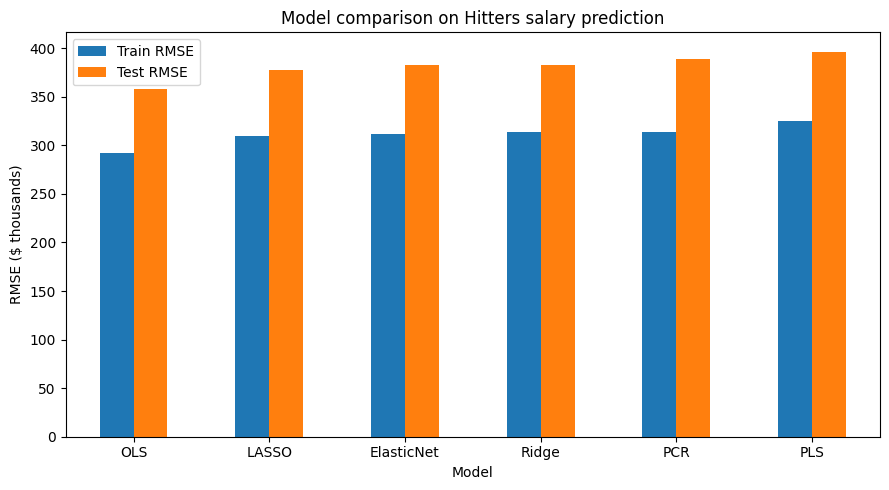

In [23]:
df_results.sort_values('Test RMSE')[['Train RMSE', 'Test RMSE']].plot(kind='bar', figsize=(9, 5))
plt.ylabel('RMSE ($ thousands)')
plt.title('Model comparison on Hitters salary prediction')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Checkpoint D (final) — sample answer**

1. The regularized models (Ridge/LASSO/ElasticNet) and PLS typically edge out plain OLS on test RMSE, because
   Hitters has correlated career-total vs. season-total statistics (e.g. `CHits` vs `Hits`) that inflate OLS
   variance.
2. Plain OLS usually has the largest overfitting gap (test RMSE noticeably worse than train RMSE) since it has no
   variance-reducing penalty and 19 correlated predictors relative to ~210 training rows.
3. PLS often reaches its best cross-validated RMSE with fewer components than PCR needs, because PLS components
   are built to correlate with the *target*, not just to capture variance in X — so each PLS component tends to
   carry more predictive information per component than a PCA component does.
4. For interpretability with a non-technical stakeholder, **LASSO** is usually the best compromise: it keeps the
   original, named variables (unlike PCR/PLS, whose components are abstract linear combinations) while
   simplifying the model by zeroing out unhelpful predictors. Plain OLS is also interpretable but is more likely
   to have unstable, hard-to-explain coefficient signs when predictors are collinear.


## Summary

You've now implemented, from scratch, the full workflow: MLR diagnostics → multicollinearity handling → statistical and performance-based feature selection → cross-validated shrinkage with coefficient-path visualization → a leakage-free PCR/PLS pipeline → and a fair final model comparison.